In [1]:
import json

import gc_utils
import h5py
import halo_analysis as halo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import utilities as ut

In [2]:
def eccentricity_from_rv_pointmass(rvec, vvec, M_host, M_sat=0.0):
    G = 4.30091e-6  # kpc (km/s)^2 / Msun
    # pos_* in kpc, vel_* in km/s, masses in Msun
    r = np.linalg.norm(rvec)
    hvec = np.cross(rvec, vvec)
    # h = np.linalg.norm(hvec)
    mu = G * (M_host + M_sat)
    # avoid division by zero
    if r == 0 or mu == 0:
        return np.nan
    # e vector
    ev = np.cross(vvec, hvec) / mu - (rvec / r)
    e = np.linalg.norm(ev)
    return float(e)

In [3]:
def get_full(grp_lst, proc_data, it_min, it_max):
    grp_dict = {grp: {} for grp in grp_lst if grp != 0}

    for grp in grp_dict.keys():
        log_num_gc = []

        et_norm_avg = []
        et_norm_std = []
        jr_avg = []
        jr_std = []
        jp_avg = []
        jp_std = []
        jz_avg = []
        jz_std = []

        com_avg = []
        com_spd_avg = []
        com_spd_std = []  # small means uniform structure, large means possibly clumpy

        sig_3D_avg = []
        log_mass_gc = []

        beta_avg = []

        for it in range(it_min, it_max + 1):
            it_id = gc_utils.iteration_name(it)
            snp_600 = proc_data[it_id]["snapshots"]["snap600"]
            grp_msk = snp_600["group_id"][()] == grp

            # conserved quantities
            et_norm = snp_600["et_norm"][grp_msk]

            # ignore iterations of groups with low gc count
            num_gc = len(et_norm)
            if num_gc <= 2:
                continue

            jcyl = snp_600["j.cyl"][grp_msk]
            jr = jcyl[:, 0]
            jp = jcyl[:, 1]
            jz = jcyl[:, 2]

            v_xyz = snp_600["vel.xyz"][grp_msk]
            vx = v_xyz[:, 0]
            vy = v_xyz[:, 1]
            vz = v_xyz[:, 2]

            sig_x = np.std(vx)
            sig_y = np.std(vy)
            sig_z = np.std(vz)

            sig_3D = np.sqrt(sig_x**2 + sig_y**2 + sig_z**2)

            v_sph = snp_600["vel.sph"][grp_msk]
            vr = v_sph[:, 0]
            vtheta = v_sph[:, 1]
            vphi = v_sph[:, 2]

            sig_r = np.std(vr)
            sig_theta = np.std(vtheta)
            sig_phi = np.std(vphi)

            beta = 1 - (sig_theta**2 + sig_phi**2) / (2 * sig_r**2)

            # CoM
            xyz = snp_600["pos.xyz"][grp_msk]
            mass = 10 ** snp_600["mass"][grp_msk]

            c_x = np.sum(xyz[:, 0] * mass) / np.sum(mass)
            c_y = np.sum(xyz[:, 1] * mass) / np.sum(mass)
            c_z = np.sum(xyz[:, 2] * mass) / np.sum(mass)

            com = np.array([c_x, c_y, c_z])
            com_d = np.linalg.norm(com)

            # d_c = np.sqrt((c_x - xyz[:, 0]) ** 2 + (c_y - xyz[:, 1]) ** 2 + (c_z - xyz[:, 2]) ** 2)
            d_c = []
            for pos in xyz:
                d_c.append(ut.coordinate.get_distances(com, pos, total_distance=True))

            # append lists

            log_num_gc.append(np.log10(num_gc))  # logged
            log_mass_gc.append(np.log10(np.sum(mass)))

            et_norm_avg.append(np.mean(et_norm))
            et_norm_std.append(np.std(et_norm))

            jr_avg.append(np.mean(np.log10(jr)))  # logged
            jr_std.append(np.std(np.log10(jr)))  # logged
            jp_avg.append(np.mean(jp))
            jp_std.append(np.std(jp))
            jz_avg.append(np.mean(np.log10(jz)))  # logged
            jz_std.append(np.std(np.log10(jz)))  # logged

            com_avg.append(com_d)
            com_spd_avg.append(np.mean(d_c))
            com_spd_std.append(np.std(d_c))

            sig_3D_avg.append(sig_3D)
            beta_avg.append(beta)

        weigh = 10 ** np.array(log_num_gc)

        grp_dict[grp]["log_num_gc"] = np.nanmean(log_num_gc)
        grp_dict[grp]["log_mass_gc"] = np.nanmean(log_mass_gc)

        grp_dict[grp]["et_norm_avg"] = np.sum(weigh * np.array(et_norm_avg)) / np.sum(weigh)
        grp_dict[grp]["et_norm_std"] = np.sqrt(
            np.sum((weigh - 1) * np.array(et_norm_std) ** 2) / np.sum(weigh - 1)
        )

        grp_dict[grp]["log_jr_avg"] = np.sum(weigh * np.array(jr_avg)) / np.sum(weigh)
        grp_dict[grp]["log_jr_std"] = np.sqrt(np.sum((weigh - 1) * np.array(jr_std) ** 2) / np.sum(weigh - 1))
        grp_dict[grp]["jp_avg"] = np.sum(weigh * np.array(jp_avg)) / np.sum(weigh)
        grp_dict[grp]["jp_std"] = np.sqrt(np.sum((weigh - 1) * np.array(jp_std) ** 2) / np.sum(weigh - 1))
        grp_dict[grp]["log_jz_avg"] = np.sum(weigh * np.array(jz_avg)) / np.sum(weigh)
        grp_dict[grp]["log_jz_std"] = np.sqrt(np.sum((weigh - 1) * np.array(jz_std) ** 2) / np.sum(weigh - 1))

        grp_dict[grp]["com_avg"] = np.sum(weigh * np.array(com_avg)) / np.sum(weigh)
        grp_dict[grp]["com_spd_avg"] = np.sum(weigh * np.array(com_spd_avg)) / np.sum(weigh)
        grp_dict[grp]["com_spd_std"] = np.sqrt(
            np.sum((weigh - 1) * np.array(com_spd_std) ** 2) / np.sum(weigh - 1)
        )

        grp_dict[grp]["log_com_avg"] = np.log10(grp_dict[grp]["com_avg"])

        grp_dict[grp]["sig_3D_avg"] = np.sum(weigh * np.array(sig_3D_avg)) / np.sum(weigh)
        grp_dict[grp]["beta_avg"] = np.sum(weigh * np.array(beta_avg)) / np.sum(weigh)

    return grp_dict

In [4]:
def gal_data(grp_lst, halt, gal_dict, sim, sim_data, fire_dir):
    for grp in grp_lst:
        ############################################################
        tidx = np.where(halt["tid"] == grp)[0][0]
        pre_dis_snp = halt["snapshot"][tidx]

        cidx = halt["catalog.index"][tidx]
        hal_pre_dis_snp = halo.io.IO.read_catalogs("index", pre_dis_snp, fire_dir)

        sat_snp = hal_pre_dis_snp["infall.first.snapshot"][cidx]

        sat_tid = gc_utils.get_halo_prog_at_snap(halt, grp, sat_snp)
        sat_tidx = np.where(halt["tid"] == sat_tid)[0][0]
        sat_cidx = halt["catalog.index"][sat_tidx]

        m_halo_sat = halt["mass"][sat_tidx]
        log_m_halo_sat = np.log10(m_halo_sat)

        vel_circ_max_sat = halt["vel.circ.max"][sat_tidx]

        hal_sat = halo.io.IO.read_catalogs("index", sat_snp, fire_dir)

        sat_host_tid = gc_utils.get_halo_prog_at_snap(halt, sim_data[sim]["halo"], sat_snp)
        sat_host_tidx = np.where(halt["tid"] == sat_host_tid)[0][0]

        x, y, z = ut.coordinate.get_distances(
            halt["position"][sat_tidx],
            halt["position"][sat_host_tidx],
            hal_sat.info["box.length"],
            hal_sat.snapshot["scalefactor"],
            False,
        )  # [kpc physical]

        vx, vy, vz = ut.coordinate.get_velocity_differences(
            halt["velocity"][sat_tidx],
            halt["velocity"][sat_host_tidx],
            halt["position"][sat_tidx],
            halt["position"][sat_host_tidx],
            hal_sat.info["box.length"],
            hal_sat.snapshot["scalefactor"],
            hal_sat.snapshot["time.hubble"],
            False,
        )  # [km/s]

        lx_sat = y * vz - z * vy
        ly_sat = z * vx - x * vz
        lz_sat = x * vy - y * vx
        ltot_sat = np.linalg.norm([lx_sat, ly_sat, lz_sat])

        inc_sat = np.degrees(np.arccos(lz_sat / ltot_sat))

        star_disp = hal_sat["star.vel.std.50"][
            sat_cidx
        ]  # stellar velocity dispersion (standard deviation) at R_50
        star_rad = hal_sat["star.radius.50"][sat_cidx]

        Ob = sim_data[sim]["Ob"]
        Om = sim_data[sim]["Om"]
        fb = Ob / Om

        M_host = halt["mass"][sat_host_tidx] / (1 - fb)
        M_sat = halt["mass"][sat_tidx] / (1 - fb)

        e_sat = eccentricity_from_rv_pointmass([x, y, z], [vx, vy, vz], M_host, M_sat)

        Ek_sat = M_sat * 0.5 * np.linalg.norm([vx, vy, vz])
        Ek_sat = np.log10(Ek_sat)
        spin_sat = halt["spin.bullock"][sat_tidx]

        # add to dictionary
        for prop_str in gal_dict[grp].keys():
            prop = locals()[prop_str]
            gal_dict[grp][prop_str] = prop

    return gal_dict

In [5]:
# about 2 minutes to run on 101 iterations
it_min = 0
it_max = 100

# snap_lim = 46
sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/One_Touch/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"

# fire_dir = sim_dir + sim + "/" + sim + "_res7100"

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
snap_lst = pub_snaps["index"].to_numpy()
time_lst = pub_snaps["time_Gyr"].to_numpy()

sim = "m12i"
all_data = sim_dir + "/" + sim + "/" + sim + "_res7100/" + "snapshot_times.txt"
all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
all_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]


# sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_lst = ["m12i"]
# it_lst = np.arange(it_min, it_max + 1)

grp_dict = []
for sim in sim_lst:
    grp_file = sim_dir + sim + "/" + "gc_groups.json"
    with open(grp_file, "r") as file:
        grp_col_dict = json.load(file)
    grp_lst = [int(grp) for grp in grp_col_dict[sim].keys() if int(grp) != 0]
    grp_dict.append(grp_lst)

sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

In [6]:
grp_prop_dict = []
for i, sim in enumerate(sim_lst):
    grp_lst = grp_dict[i]
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    hold_dict = get_full(grp_lst, proc_data, it_min, it_max)
    grp_prop_dict.append(hold_dict)

    proc_data.close()

In [7]:
gc_prop_lst = [
    "log_num_gc",
    "log_mass_gc",
    "et_norm_avg",
    "et_norm_std",
    "log_jr_avg",
    "log_jr_std",
    "jp_avg",
    "jp_std",
    "log_jz_avg",
    "log_jz_std",
    "log_com_avg",
    "com_spd_avg",
    "sig_3D_avg",
    "beta_avg",
]

gal_prop_lst = [
    "log_m_halo_sat",  # halo mass of galaxy when first became satellite
    "lx_sat",  # lx of galaxy when first became satellite
    "ly_sat",  # ly of galaxy when first became satellite
    "lz_sat",  # lz of galaxy when first became satellite
    "ltot_sat",  # l_tot of galaxy when first became satellite
    "vel_circ_max_sat",  # max circular velocity of galaxy when first became satellite
    "inc_sat",  # inclination of galaxy when first became satellite
    "e_sat",  # eccentricity of galaxy when first became satellite
    "star_disp",  # stellar velocity dispersion (standard deviation) at R_50 [km/s]
    "star_rad",  # R_50
    "Ek_sat",
    "spin_sat",
]

gal_prop_dict = []
for i, _ in enumerate(grp_dict):
    grp_lst = grp_dict[i]
    gal_dict = {grp: {prop_str: {} for prop_str in gal_prop_lst} for grp in grp_lst if grp != 0}
    gal_prop_dict.append(gal_dict)

In [8]:
for i, _ in enumerate(gal_prop_dict):
    sim = sim_lst[i]
    gal_prop = gal_prop_dict[i]
    # grp_prop = grp_prop_dict[i]

    grp_lst = grp_dict[i]

    fire_dir = sim_dir + sim + "/" + sim + "_res7100"
    halt = gc_utils.get_halo_tree(sim, sim_dir, assign_hosts_rotation=True)

    gal_prop_dict[i] = gal_data(grp_lst, halt, gal_prop, sim, sim_data, fire_dir)

Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.34s/it]



# in utilities.simulation.Snapshot():
* reading:  Users/z5114326/Documents/simulations/m12i/m12i_res7100/snapshot_times.txt

  using snapshot index = 126, redshift = 2.852

* read 24585 halos from:  Users/z5114326/Documents/simulations/m12i/m12i_res7100/halo/rockstar_dm/catalog_hdf5/halo_126.hdf5

# in halo_analysis.halo_io.Particle():
* read 24585 halos, 214 have star particles, from:  Users/z5114326/Documents/simulations/m12i/m12i_res7100/halo/rockstar_dm/catalog_hdf5/star_126.hdf5
* assigning primary host and coordinates wrt it to halo catalog...  finished


# in utilities.simulation.Snapshot():
* reading:  Users/z5114326/Documents/simulations/m12i/m12i_res7100/snapshot_times.txt

  using snapshot index = 100, redshift = 3.571

* read 16267 halos from:  Users/z5114326/Documents/simulations/m12i/m12i_res7100/halo/rockstar_dm/catalog_hdf5/halo_100.hdf5

# in halo_analysis.halo_io.Particle():
* read 16267 halos, 237 have star particles, from:  Users/z5114326/Documents/simulations/m12i

In [11]:
grp_labels = [
    r"$\overline{\text{log}N_{\text{GC}}}$",
    r"$\overline{\text{log}M_{\text{GC}}}$",
    r"$\overline{\text{e}}$",
    r"$\sigma_{\text{e}}$",
    r"$\overline{\text{log J}_{r}}$",
    r"$\sigma_{\text{log J}_{r}}$",
    r"$\overline{J_{\phi}}$",
    r"$\sigma_{J_{\phi}}$",
    r"$\overline{\text{log J}_{z}}$",
    r"$\sigma_{\text{log J}_{z}}$",
    r"$\overline{\text{log }r_{\text{CoM}}}$",
    r"$\overline{r_\text{sub}}$",
    r"$\overline{\sigma_{3D}}$",
    r"$\overline{\beta}$",
]

gal_labels = [
    r"$\text{log }M_{\text{halo}}$",
    r"$\text{l}_{\text{x}}$",
    r"$\text{l}_{\text{y}}$",
    r"$\text{l}_{\text{z}}$",
    r"$\text{l}_{\text{total}}$",
    r"$\text{V}_{\text{circ, max}}$",
    r"$i$",
    r"$e$",
    r"$\sigma_{3D, star}$",
    r"$R_{50, star}$",
    r"$E_{k}$",
    r"$\lambda$",
]

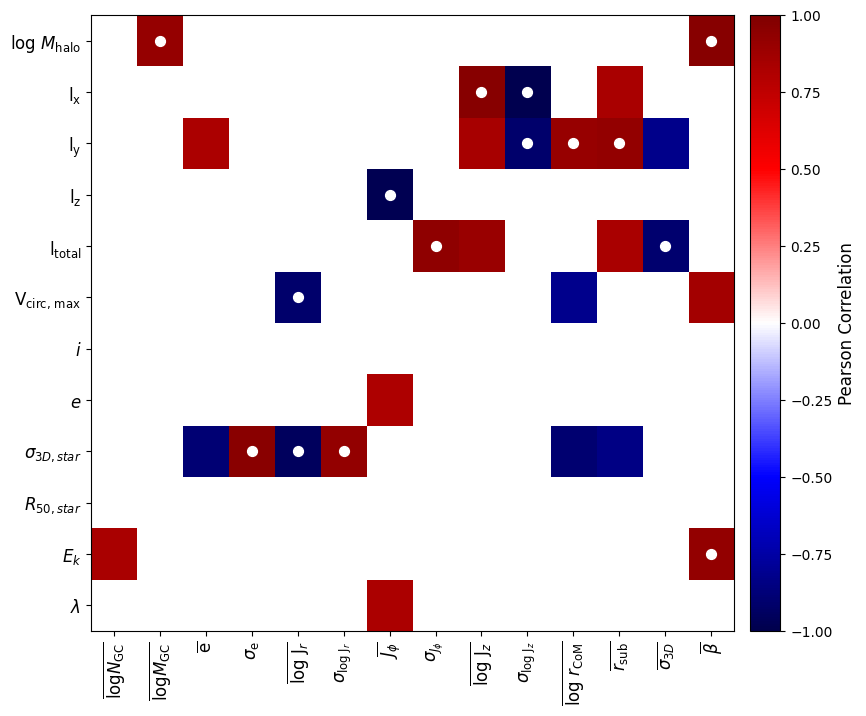

In [18]:
# -------------------------------
# Parameters
consider_pvalue = True
pvalue_limit = 0.05
sig_lim = 0.9

# Example lists (replace with your own)
# gal_prop_lst = ["Mstar", "Rhalf", "sigma"]
# gc_prop_lst = ["color", "mass", "age"]

num_rows = len(gal_prop_lst)
num_cols = len(gc_prop_lst)

# Array to store correlations
cor_arr = np.zeros((num_rows, num_cols))

# -------------------------------
# Compute correlations
for j, gal_prop in enumerate(gal_prop_lst):
    for i, gc_prop in enumerate(gc_prop_lst):
        gal_lst = []
        gc_lst = []
        for sim_idx, sim in enumerate(sim_lst):
            for grp in grp_dict[sim_idx]:
                prop_hold = grp_prop_dict[sim_idx][grp][gc_prop]
                if np.isnan(prop_hold):
                    continue
                gc_lst.append(prop_hold)
                gal_lst.append(gal_prop_dict[sim_idx][grp][gal_prop])

        # Pearson correlation
        if len(gc_lst) > 1:  # need at least 2 points
            p_stats = stats.pearsonr(gc_lst, gal_lst)
            cor_val = p_stats.statistic
            # Consider p-value if requested
            if consider_pvalue and p_stats.pvalue > pvalue_limit:
                cor_val = np.nan
        else:
            cor_val = np.nan

        cor_arr[j, i] = cor_val

# -------------------------------
# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cor_arr, vmin=-1, vmax=1, cmap="seismic", aspect="auto")

# Add colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Pearson Correlation", fontsize=12)

ax.set_xticks(np.arange(0, len(grp_labels)), grp_labels, rotation=90, fontsize=12, fontweight="bold")
ax.set_yticks(np.arange(0, len(gal_labels)), gal_labels, rotation=0, fontsize=12, fontweight="bold")

for j, gal_prop in enumerate(gal_prop_lst):
    for i, gc_prop in enumerate(gc_prop_lst):
        if np.abs(cor_arr[j, i]) >= sig_lim:
            ax.scatter(i, j, c="w", s=50)